#### Wpływ metod inicjalizacji wag na proces uczenia

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [21]:
# --- sztuczny zbiór danych 2D ---
np.random.seed(0)
N = 200
X = np.random.randn(N, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(np.float32)  # prosta granica decyzyjna

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1,1)

In [23]:
# --- MLP ---
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=20):
        super().__init__()
        self.l1 = nn.Linear(input_dim, hidden_dim)
        self.l2 = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        x = F.relu(self.l1(x))
        x = torch.sigmoid(self.l2(x))
        return x

In [25]:
# --- inicjalizacje ---
init_methods = {
    "normal_(0,0.1)": lambda w: nn.init.normal_(w, mean=0.0, std=0.1),
    "uniform_(-0.1,0.1)": lambda w: nn.init.uniform_(w, a=-0.1, b=0.1),
    "xavier_normal_": lambda w: nn.init.xavier_normal_(w),
    "kaiming_normal_": lambda w: nn.init.kaiming_normal_(w, nonlinearity='relu')
}

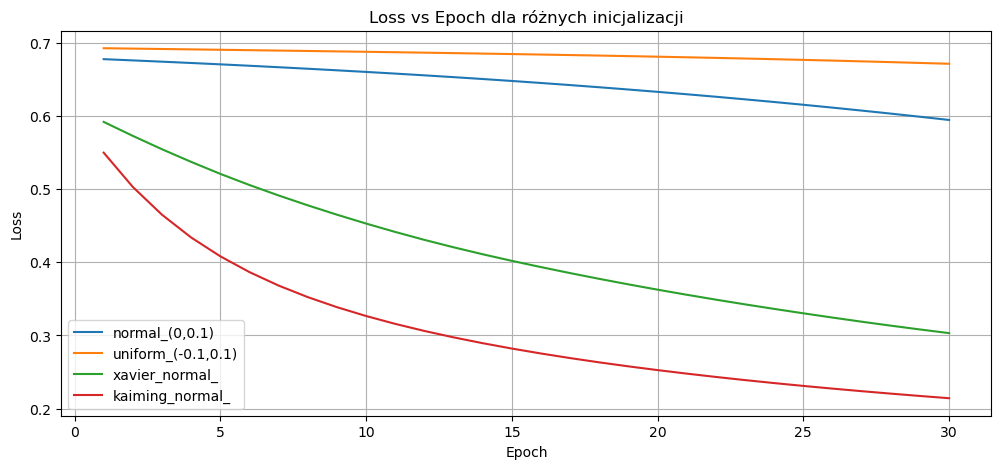

In [27]:
num_epochs = 30
lr = 0.1

plt.figure(figsize=(12,5))

# --- eksperyment ---
for name, init_fn in init_methods.items():
    model = SimpleMLP()
    init_fn(model.l1.weight)
    init_fn(model.l2.weight)
    nn.init.zeros_(model.l1.bias)
    nn.init.zeros_(model.l2.bias)
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        out = model(X_tensor)
        loss = F.binary_cross_entropy(out, y_tensor)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    plt.plot(range(1,num_epochs+1), losses, label=name)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch dla różnych inicjalizacji")
plt.legend()
plt.grid(True)
plt.show()